<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/TP_R%C3%89GRESSION_LIN%C3%89AIRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#seed pour reprouductibilité
np.random.seed(0)

#Générer 2 variables explicatives X1 et X2
n_samples=100
X1=np.random.rand(n_samples)*10
X2=np.random.rand(n_samples)*5

#Bruit aleatoire
epsilon =np.random.normal(0,2,size=n_samples)

y=4*X1 - 2*X2+1+epsilon

#construire la matrice X
X =np.column_stack((X1,X2))

# Vérification des dimensions
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


In [3]:
# Ajouter la colonne de biais
X_b=np.c_[np.ones((n_samples,1)),X]
# Solution analytique
beta_hat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Coefficients:", beta_hat)
# beta_hat[0] = intercept, beta_hat[1] = coeff X1, beta_hat[2] = coeff X2


Coefficients: [ 1.61461061  3.88967089 -2.10353871]


In [4]:
# Initialisation
beta = np.zeros(3)  # [intercept, b1, b2]
alpha = 0.001
n_iter = 10000
for _ in range(n_iter):
    y_pred = X_b @ beta
    gradient = -2 * X_b.T @ (y - y_pred) / n_samples
    beta -= alpha * gradient

print("Coefficients (GD):", beta)

Coefficients (GD): [ 1.47486063  3.90049579 -2.07652421]


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 1.6146106135943068
Coefficients: [ 3.88967089 -2.10353871]


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("R²:", r2)





MSE: 3.3264654842680152
R²: 0.9765518919763296


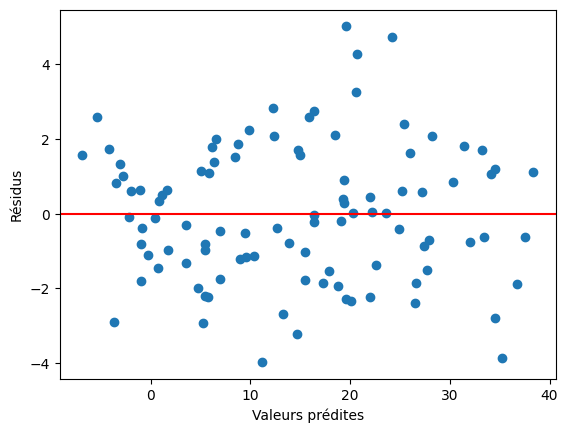

In [9]:
# Tracer les résidus
residuals = y - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.show()

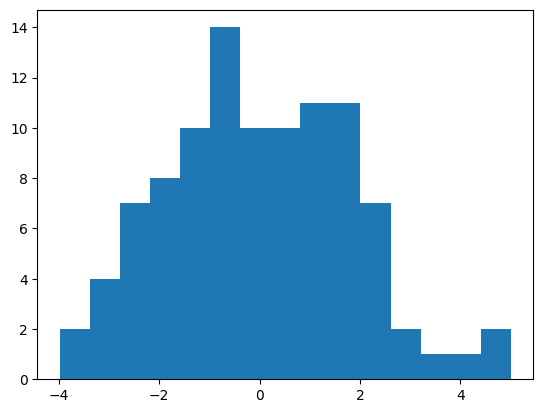

In [10]:
plt.hist(residuals, bins=15)
plt.show()


In [11]:
# Créer une variable très corrélée avec X1
X3 = X1 * 0.9 + np.random.normal(0, 0.1, n_samples)
X_multi = np.column_stack((X1, X2, X3))

model_multi = LinearRegression()
model_multi.fit(X_multi, y)
print("Coefficients multicolinéarité:", model_multi.coef_)


Coefficients multicolinéarité: [ 2.25123087 -2.09338263  1.80753556]


In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ridge
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge.fit(X_multi, y)
print("Ridge coefficients:", ridge.named_steps['ridge'].coef_)

# Lasso
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])
lasso.fit(X_multi, y)
print("Lasso coefficients:", lasso.named_steps['lasso'].coef_)


Ridge coefficients: [ 5.636122   -2.86883848  5.52811988]
Lasso coefficients: [ 7.45982212 -2.80565261  3.66534068]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Linear
lin = LinearRegression().fit(X_train, y_train)
print("R² Linear Test:", lin.score(X_test, y_test))

# Ridge
ridge.fit(X_train, y_train)
print("R² Ridge Test:", ridge.score(X_test, y_test))

# Lasso
lasso.fit(X_train, y_train)
print("R² Lasso Test:", lasso.score(X_test, y_test))


R² Linear Test: 0.9700833181719932
R² Ridge Test: 0.9696902577413002
R² Lasso Test: 0.9691662330475912


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.216e+00, tolerance: 1.207e+00
  model = cd_fast.enet_coordinate_descent(
